
===== PERFORMANCE =====
Final Capital: 10916.82
Cumulative Return: 9.17%
Sharpe Ratio: 1.34
Max Drawdown: 2.53%


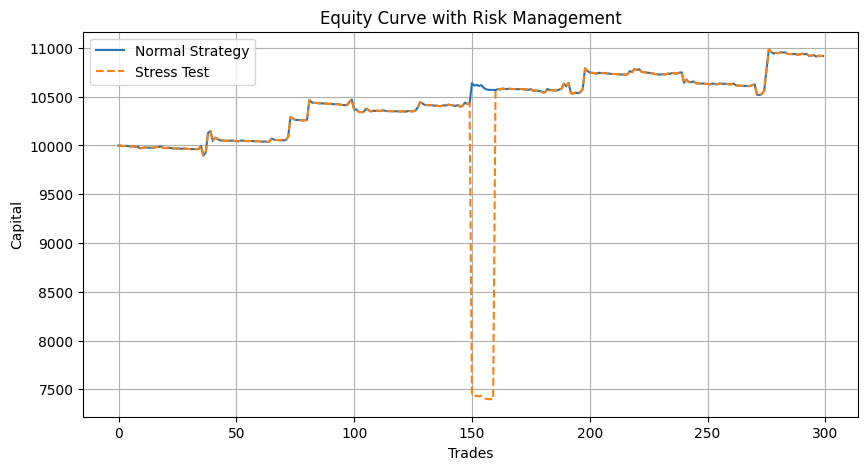

In [1]:
#Implementing advanced risk management techniques in trading algos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. INITIAL SETTINGS
initial_capital = 10000
capital = initial_capital
equity_curve = []

num_trades = 300

# Risk levels
risk_levels = {
    "low": 0.01,
    "medium": 0.02,
    "high": 0.05
}

current_risk = "medium"

# Track metrics
max_capital = capital
drawdown_limit = 0.25   # 25% max drawdown

# 2. TRADE SIMULATION FUNCTION
def simulate_trade(risk_percent, volatility):
    """
    Simulates profit/loss based on risk and volatility
    """
    win_prob = 0.55 - (volatility * 0.2)  # volatility reduces win rate
    reward_risk_ratio = 2

    if np.random.rand() < win_prob:
        return risk_percent * reward_risk_ratio
    else:
        return -risk_percent

# 3. VOLATILITY SIMULATION
def get_market_volatility():
    """
    Simulates changing market volatility
    """
    return np.random.choice([0.5, 1.0, 1.5])  # low, normal, high

# 4. POSITION SIZING
def position_size(capital, risk_percent):
    """
    Fixed fractional position sizing
    """
    return capital * risk_percent

# 5. MAIN TRADING LOOP
for i in range(num_trades):

    volatility = get_market_volatility()

    # Adjust position size based on volatility
    adjusted_risk = risk_levels[current_risk] / volatility

    trade_size = position_size(capital, adjusted_risk)

    # Simulate trade outcome
    trade_return = simulate_trade(adjusted_risk, volatility)

    pnl = trade_size * trade_return
    capital += pnl

    # STOP LOSS (10% of capital)
    if pnl < -0.10 * capital:
        print(f"Stop loss triggered at trade {i}")
        capital += (-0.10 * capital)

    # DYNAMIC RISK ADJUSTMENT
    if pnl > 0:
        if current_risk == "low":
            current_risk = "medium"
        elif current_risk == "medium":
            current_risk = "high"
    else:
        if current_risk == "high":
            current_risk = "medium"
        elif current_risk == "medium":
            current_risk = "low"

    # DRAWDOWN CONTROL
    max_capital = max(max_capital, capital)
    drawdown = (max_capital - capital) / max_capital

    if drawdown > drawdown_limit:
        print("Max drawdown exceeded. Trading stopped.")
        break

    equity_curve.append(capital)

# 6. PERFORMANCE METRICS
equity_series = pd.Series(equity_curve)

returns = equity_series.pct_change().dropna()

sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()

cumulative_return = (equity_series.iloc[-1] / initial_capital) - 1

max_drawdown = np.max(
    (np.maximum.accumulate(equity_series) - equity_series) /
    np.maximum.accumulate(equity_series)
)

print("\n===== PERFORMANCE =====")
print(f"Final Capital: {capital:.2f}")
print(f"Cumulative Return: {cumulative_return*100:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown*100:.2f}%")

# 7. STRESS TESTING
def stress_test(equity_curve):
    """
    Simulate extreme market crash
    """
    stressed = equity_curve.copy()
    crash_index = len(stressed) // 2

    for i in range(crash_index, min(crash_index+10, len(stressed))):
        stressed[i] *= 0.7  # 30% crash

    return stressed

stressed_curve = stress_test(equity_curve)

# 8. VISUALIZATION
plt.figure(figsize=(10,5))
plt.plot(equity_curve, label="Normal Strategy")
plt.plot(stressed_curve, linestyle='--', label="Stress Test")
plt.title("Equity Curve with Risk Management")
plt.xlabel("Trades")
plt.ylabel("Capital")
plt.legend()
plt.grid()
plt.show()